# ELECTRUM v2: a graph-based, stereochemistry-aware update to the ELECTRUM metal fingerprint

**Markus Orsi and Angelo Frei**
*Department of Chemistry, Biochemistry and Pharmaceutical Sciences, University of Bern* *(affiliations to confirm)*

---

*Prepared as a **`Commit`** for [Digital Discovery](https://pubs.rsc.org/en/journals/journal/dd).
The `Commit` format reports **incremental advances on prior work** — updates to papers,
code or hardware. This one documents and validates **version 2** of ELECTRUM against the
originally published fingerprint.*

**Code:** [`TheFreiLab/electrum`](https://github.com/TheFreiLab/electrum) (v0.2.0) ·
**Validation:** [`electrum_val`](https://github.com/TheFreiLab/electrum_val) ·
**Original paper:** [*Digital Discovery* **4**, 3567 (2025)](https://doi.org/10.1039/D5DD00145E)

> **This notebook is the article.** Each section pairs a short write-up with the exact
> code that produces its result. It runs in two modes — a fast `QUICK` look and the
> full, paper-scale `FULL` benchmark — selected by a single flag in §2.4. All new
> outputs are written to `results/v2/` and `figures/v2/`; the original paper artefacts
> in this repository are left untouched.

## Abstract

ELECTRUM encodes a transition-metal complex as a ligand-topology block concatenated
with an 86-bit vector of the metal's ground-state electron configuration. We present
**ELECTRUM v2**, which replaces the original SMILES-hashing ligand engine with a
graph-based Morgan/ECFP engine and adds an explicit **stereochemistry channel**. We
validate v2 on the three datasets from the original study (coordination number,
oxidation state, and tmQMg quantum-mechanical properties). v2 (i) **reproduces** the
published fingerprint bit-for-bit through a retained `legacy` engine; (ii) newly
**distinguishes stereoisomers** — cis/trans, fac/mer, R/S, E/Z and Δ/Λ — that the
original fingerprint and plain Morgan collapse; (iii) is markedly **more reproducible**,
being ~invariant to how a SMILES is written (~98% of molecules) where the hash engine
is not (~46%), while also representing monoatomic ligands the old engine dropped; (iv)
is **faster**; and (v) is **comparable** to v1 on the supervised tasks — classification
within a couple of percentage points and regression differences that are small and
target-dependent, quantified here with paired confidence intervals and equivalence
tests. v2 is a drop-in successor that preserves the published behaviour while extending
the fingerprint to the stereochemistry of coordination compounds.

## 1. Introduction

Extended-connectivity fingerprints (ECFP/Morgan) describe organic molecules well but
ignore the two things that define a coordination compound: the **metal centre** and the
**geometry of its coordination sphere**. ELECTRUM ([Orsi & Frei, *Digital Discovery*
2025](https://doi.org/10.1039/D5DD00145E)) addressed the first by concatenating a ligand
fingerprint with a fixed **electron-configuration** vector of the metal. Its original
ligand engine (v1) hashed the SMILES strings of each atom's local environment with
SHA-1. That design has three practical shortcomings:

1. it is **blind to stereochemistry** — cis/transplatin, fac/mer isomers and Δ/Λ
   enantiomers map to identical vectors;
2. it **drops monoatomic ligands** (a bare halide's atom-environment string is empty and
   sets no bits); and
3. because it hashes SMILES strings, it can be **sensitive to how a SMILES is written**.

**ELECTRUM v2** rebuilds the ligand block on RDKit's Morgan generator applied to the
molecular graph, folds tetrahedral R/S and double-bond E/Z into the atom invariants
(`includeChirality`), and adds a dedicated **non-tetrahedral stereo channel** (trans
pairs + Δ/Λ handedness) for square-planar, trigonal-bipyramidal and octahedral centres.
The metal electron-configuration block is unchanged. The original engine is retained
verbatim as `electrum.legacy`.

**Contributions of this `Commit`.**

* A drop-in v2 engine that **reproduces v1 bit-for-bit** on the published inputs (§3.1).
* A **stereochemistry discrimination benchmark** showing v2 separates isomer classes v1
  cannot (§3.3).
* Evidence that v2 is **more reproducible** (SMILES-order invariance) and **more
  complete** (monoatomic ligands, 100% dataset coverage) than v1 (§3.2, §3.7).
* A **like-for-like predictive comparison** on the paper's tasks, with **paired
  confidence intervals and TOST equivalence tests** and **hyper-parameter ablations**,
  framing the engines as *comparable* rather than identical (§3.4–§3.6).
* Throughput measurements (§3.8).

## 2. Methods

### 2.1 The two engines

| | **v1 — published** | **v2 — new** |
|---|---|---|
| Location | frozen `electrum.py` (= `electrum.legacy`) | `electrum` v0.2.0 |
| Ligand block | SHA-1 hash of atom-environment SMILES | RDKit **Morgan/ECFP** on the graph |
| Radius-0 (monoatomic) | dropped | represented |
| Tetrahedral R/S, E/Z | ignored | Morgan `includeChirality` |
| cis/trans, fac/mer, Δ/Λ | ignored | **stereo channel** (trans pairs + handedness) |
| Metal block | 86-bit electron configuration | 86-bit electron configuration (identical) |

Both produce a vector of length `n_bits + 86`.

### 2.2 Datasets

The three validation datasets from the original study, all derived from the Cambridge
Structural Database (CSD).

| Dataset | Task | Target | # complexes |
|---|---|---|---|
| `coordnumber` | classification | coordination number | ~217,500 |
| `oxidationstate_46k` | classification | oxidation-state class | ~39,200 |
| `tmQMg` | regression | 20 QM properties | ~63,500 |

Each row provides disconnected ligand SMILES (`LigandSmiles`) and a metal symbol
(`Metal`) — the exact inputs used in the paper, so both engines are compared
like-for-like.

### 2.3 Benchmark protocol

* **Splitting.** `StratifiedGroupKFold` with `LigandSmiles` as the grouping key, so no
  ligand set leaks between train and test.
* **Models.** An MLP (`MLPClassifier` / `MLPRegressor`) for prediction; a 5-NN
  (Manhattan) classifier for the fingerprint ablations, since a distance-based model
  reads the representation's metric space directly.
* **Classification** reports accuracy, macro-F1 and macro ROC-AUC, with a
  **scrambled-label baseline** (labels permuted → performance should fall to chance,
  confirming real signal).
* **Regression** standardises the target on each training split (MLPs are
  scale-sensitive) and reports R² and MAE.
* **Equivalence.** Because v1 and v2 are trained on identical folds, we treat the
  per-fold **v2 − v1** difference as paired data and report a 95% confidence interval
  and a **two one-sided tests (TOST)** equivalence check against a stated practical
  margin.
* **Robustness.** Dataset **coverage** (fraction featurised without error) and
  **canonicality** (fingerprint invariance to random SMILES re-writings).

> **A note on `max_iter` / early stopping.** The paper's scripts trained the MLP for a
> fixed `max_iter` with no early stopping. To keep the full run tractable (below) we
> enable **early stopping**, applied identically to both engines, so the comparison
> remains fair. The original fixed-iteration scripts remain in the repository for exact
> reproduction of the paper's tables.

### 2.4 Environment, reproducibility, and how to run

**Install** (from the repository root):

```bash
pip install rdkit scikit-learn pandas numpy matplotlib scipy tqdm
pip install "electrum-fp @ git+https://github.com/TheFreiLab/electrum"
```

**Import handling.** This repository ships a file `electrum.py` (the frozen v1 engine),
while the new package is *also* imported as `electrum`. The setup cell loads the frozen
v1 from its file path (as `electrum_v1_frozen`) and then removes the repository
directory from `sys.path` so `import electrum` resolves to the installed v2 package.

**Run modes.** Set `QUICK = True` for a fast, subsampled pass (minutes). Set
`QUICK = False` for the **complete** benchmark: all rows, all bit sizes `[256, 512,
1024]`, the paper's MLP architecture, and the full 20-target regression panel.

**Runtime.** The `FULL` run is dominated by MLP training on the ~217k-row
coordination-number set across three bit sizes. On a 10-core Apple M4 / 16 GB this is an
**overnight-scale** job (see the live estimate printed in §2.4's code cell). To shorten
it, set `BIT_SIZES = [1024]` (roughly one third of the classification cost); for the
exhaustive bit-size sweep, an HPC node is more comfortable. Fingerprints are stored as
`uint8` to stay within 16 GB, and the equivalence/coverage/canonicality analyses use
bounded samples. Each section writes its own CSV, so a long run can be executed section
by section as checkpoints.

In [1]:
import sys, os, time, importlib.util, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore")

REPO = os.getcwd()

# 1) frozen, published v1 engine (for validation and as the v1 baseline)
_spec = importlib.util.spec_from_file_location(
    "electrum_v1_frozen", os.path.join(REPO, "electrum.py"))
electrum_v1_frozen = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(electrum_v1_frozen)

# 2) make the installed v2 package win over the local electrum.py
sys.path[:] = [p for p in sys.path if os.path.abspath(p or ".") != REPO]

import electrum
from electrum import calculate_fingerprint, calculate_fingerprints
from electrum.metals import N_METAL_BITS

print("v2 package :", electrum.__file__)
print("v2 version :", electrum.__version__)
print("v1 frozen  :", electrum_v1_frozen.__file__)

v2 package : /Users/orsim3/Developer/electrum_val/.venv/lib/python3.12/site-packages/electrum/__init__.py
v2 version : 0.2.0
v1 frozen  : /Users/orsim3/Developer/electrum_val/electrum.py


In [2]:
# ------------------------------------------------------------------ CONFIG
QUICK = True          # <-- set False for the full, paper-scale benchmark

SEED   = 42
RADIUS = 2
N_METAL = N_METAL_BITS
np.random.seed(SEED)

if QUICK:
    SUBSAMPLE   = 3000
    BIT_SIZES   = [1024]
    MLP_HIDDEN  = (256, 128, 64)
    MLP_MAXITER = 300
    N_SPLITS    = 3
    REG_TARGETS = ["tzvp_electronic_energy", "polarisability", "heat_capacity"]
    REPRO_N     = 200
    EQ_SPLITS, EQ_REPEATS, EQ_SAMPLE = 5, 2, 3000
    COVERAGE_N  = 5000
    CANON_N     = 200
else:
    SUBSAMPLE   = None                        # all rows
    BIT_SIZES   = [256, 512, 1024]            # set to [1024] to cut classification ~3x
    MLP_HIDDEN  = (512, 256, 128, 64, 32)     # paper architecture
    MLP_MAXITER = 1000
    N_SPLITS    = 3
    REG_TARGETS = [                           # the paper's full 20-target panel
        "tzvp_lumo_energy", "tzvp_homo_energy", "tzvp_homo_lumo_gap",
        "homo_lumo_gap_delta", "tzvp_electronic_energy", "electronic_energy_delta",
        "tzvp_dispersion_energy", "dispersion_energy_delta", "enthalpy_energy",
        "enthalpy_energy_correction", "gibbs_energy", "gibbs_energy_correction",
        "zpe_correction", "heat_capacity", "entropy", "tzvp_dipole_moment",
        "dipole_moment_delta", "polarisability", "lowest_vibrational_frequency",
        "highest_vibrational_frequency",
    ]
    REPRO_N     = 2000
    EQ_SPLITS, EQ_REPEATS, EQ_SAMPLE = 5, 4, 12000
    COVERAGE_N  = None                        # all rows
    CANON_N     = 500

RESULTS_DIR = os.path.join(REPO, "results", "v2")
FIG_DIR     = os.path.join(REPO, "figures", "v2")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

DATASETS = {
    "coordnumber":    dict(path="datasets/coordnumber.csv",        target="classification", n=217518),
    "oxidationstate": dict(path="datasets/oxidationstate_46k.csv", target="classification", n=39167),
    "tmQMg":          dict(path="datasets/tmQMg.csv",              target=None,             n=63467),
}

print("mode:", "QUICK" if QUICK else "FULL", "| bit sizes:", BIT_SIZES,
      "| MLP:", MLP_HIDDEN, "| folds:", N_SPLITS)

mode: QUICK | bit sizes: [1024] | MLP: (256, 128, 64) | folds: 3


In [3]:
# ------------------------------------------------- rough a-priori runtime estimate
from sklearn.neural_network import MLPClassifier as _MLPc

_dfp = pd.read_csv(DATASETS["oxidationstate"]["path"], nrows=4000).dropna(
    subset=["LigandSmiles", "Metal"])
_Xp = np.array(calculate_fingerprints(list(_dfp["LigandSmiles"]), list(_dfp["Metal"]),
                                      radius=RADIUS, n_bits=1024), dtype=np.uint8)
_yp = _dfp["classification"].to_numpy()
_t = time.time()
_m = _MLPc(hidden_layer_sizes=MLP_HIDDEN, max_iter=12, random_state=SEED).fit(_Xp, _yp)
_s_per_iter_per_row = (time.time() - _t) / _m.n_iter_ / len(_dfp)

EFF_ITERS = 60 if MLP_MAXITER <= 300 else 150   # assumed effective iters w/ early stop

def _fit_seconds(n_rows):
    return _s_per_iter_per_row * n_rows * (2 / 3) * EFF_ITERS   # 2/3 train per fold

est = 0.0
for name, cfg in DATASETS.items():
    rows = min(cfg["n"], SUBSAMPLE) if SUBSAMPLE else cfg["n"]
    if cfg["target"]:                       # classification: engines x bits x folds x (true+scrambled)
        est += 2 * len(BIT_SIZES) * N_SPLITS * 2 * _fit_seconds(rows)
    else:                                   # regression: targets x engines x folds
        est += len(REG_TARGETS) * 2 * N_SPLITS * _fit_seconds(rows)
est += 2 * len(["clf", "reg"]) * EQ_SPLITS * EQ_REPEATS * _fit_seconds(min(EQ_SAMPLE, 40000))

print(f"measured MLP cost: {_s_per_iter_per_row*1e6:.2f} us / iter / row "
      f"(assuming ~{EFF_ITERS} effective iterations)")
print(f"rough estimate for this config: ~{est/60:.0f} min (~{est/3600:.1f} h) of MLP time")
print("note: order-of-magnitude only; BLAS uses all cores, early stopping varies.")

measured MLP cost: 10.42 us / iter / row (assuming ~60 effective iterations)
rough estimate for this config: ~2 min (~0.0 h) of MLP time
note: order-of-magnitude only; BLAS uses all cores, early stopping varies.


## 3. Results and discussion

### 3.1 v2 reproduces v1 bit-for-bit

The new package retains the original SMILES-hash engine as `electrum.legacy`. We verify
that it is byte-identical to the **frozen** `electrum.py` in this repository, on samples
from every dataset — so nothing in the published pipeline regresses.

In [4]:
def repro_check(path, n=REPRO_N):
    df = pd.read_csv(path, nrows=n)
    mism = sum(
        not np.array_equal(
            np.asarray(electrum_v1_frozen.calculate_fingerprint(lig, met, RADIUS, 1024)),
            np.asarray(electrum.legacy.calculate_fingerprint(lig, met, RADIUS, 1024)))
        for lig, met in zip(df["LigandSmiles"], df["Metal"]))
    return len(df), mism

repro_df = pd.DataFrame(
    [{"dataset": n, "n_checked": c, "mismatches": m, "identical": m == 0}
     for n, cfg in DATASETS.items() for c, m in [repro_check(cfg["path"])]])
repro_df.to_csv(os.path.join(RESULTS_DIR, "reproducibility_check.csv"), index=False)
assert repro_df["identical"].all()
print("PASS: electrum.legacy reproduces the published v1 fingerprint bit-for-bit.")
repro_df

PASS: electrum.legacy reproduces the published v1 fingerprint bit-for-bit.


,dataset,n_checked,mismatches,identical
0,coordnumber,200,0,True
1,oxidationstate,200,0,True
2,tmQMg,200,0,True


### 3.2 What v2 adds on small examples

**Monoatomic ligands.** In v1 a bare halide's atom environment hashed to an empty string
and set no ligand bits, so `Cl⁻` and `Br⁻` ligands were indistinguishable in the
topological block. v2's Morgan engine captures the radius-0 environment, so they differ.
**Metal auto-detection** recovers the centre from a connected coordination SMILES.

In [5]:
cl_v1 = np.asarray(electrum_v1_frozen.calculate_fingerprint("Cl", "Fe", RADIUS, 1024))
br_v1 = np.asarray(electrum_v1_frozen.calculate_fingerprint("Br", "Fe", RADIUS, 1024))
cl_v2 = calculate_fingerprint("Cl", "Fe", RADIUS, 1024)
br_v2 = calculate_fingerprint("Br", "Fe", RADIUS, 1024)
print("v1 distinguishes Cl vs Br ligand block:", not np.array_equal(cl_v1[:1024], br_v1[:1024]))
print("v2 distinguishes Cl vs Br ligand block:", not np.array_equal(cl_v2[:1024], br_v2[:1024]))

auto = calculate_fingerprint("Cl[Pt@SP1](Cl)([NH3])[NH3]")
told = calculate_fingerprint("Cl[Pt@SP1](Cl)([NH3])[NH3]", metal="Pt")
print("metal auto-detection matches explicit Pt:", np.array_equal(auto, told))

v1 distinguishes Cl vs Br ligand block: False
v2 distinguishes Cl vs Br ligand block: True
metal auto-detection matches explicit Pt: True


### 3.3 Stereochemistry discrimination

The capability that motivates v2. We assemble curated **stereoisomer pairs** — same
atoms and bonds, different 3D arrangement — spanning the types v2 targets, and test
whether each engine maps the two isomers to **different** vectors. Engines: **v2**
(full), **v2 without the stereo channel**, **v1** (published), and **plain Morgan**
(ligand block only, no metal, no stereo).

In [6]:
from rdkit import Chem
from rdkit.Geometry import Point3D
from electrum.stereo import stereo_features
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from electrum.metals import metal_vector

_OCT = [(1,0,0),(-1,0,0),(0,1,0),(0,-1,0),(0,0,1),(0,0,-1)]
def _octahedral(placements, center="Fe"):
    rw = Chem.RWMol(); c = rw.AddAtom(Chem.Atom(center)); donors = []
    for el, _ in placements:
        i = rw.AddAtom(Chem.Atom(el)); donors.append(i); rw.AddBond(c, i, Chem.BondType.SINGLE)
    m = rw.GetMol(); conf = Chem.Conformer(m.GetNumAtoms()); conf.SetAtomPosition(c, Point3D(0.,0.,0.))
    for i, (_, v) in zip(donors, placements):
        x,y,z = _OCT[v]; conf.SetAtomPosition(i, Point3D(float(x),float(y),float(z)))
    m.AddConformer(conf)
    Chem.SanitizeMol(m, sanitizeOps=Chem.SanitizeFlags.SANITIZE_ALL ^ Chem.SanitizeFlags.SANITIZE_PROPERTIES)
    Chem.AssignStereochemistryFrom3D(m); return m
_lambda = _octahedral([("F",0),("Cl",1),("Br",2),("I",3),("B",4),("P",5)])
_delta  = _octahedral([("F",0),("Cl",1),("Br",2),("I",3),("B",5),("P",4)])

PAIRS = [
    ("cisplatin / transplatin", "cis/trans (SP)",
     "Cl[Pt@SP1](Cl)([NH3])[NH3]", "Cl[Pt@SP2](Cl)([NH3])[NH3]", "Pt"),
    ("cis/trans-[Co(NH3)4Cl2]", "cis/trans (OH)",
     "Cl[Co@OH1]([NH3])([NH3])([NH3])([NH3])Cl", "Cl[Co@OH2]([NH3])([NH3])([NH3])([NH3])Cl", "Co"),
    ("fac/mer-[Co(NH3)3Cl3]", "fac/mer (OH)",
     "Cl[Co@OH1](Cl)(Cl)([NH3])([NH3])[NH3]", "Cl[Co@OH8](Cl)(Cl)([NH3])([NH3])[NH3]", "Co"),
    ("D/L-alanine ligand", "R/S (tetrahedral)", "N[C@@H](C)C(=O)O", "N[C@H](C)C(=O)O", "Fe"),
    ("E/Z-but-2-ene ligand", "E/Z (double bond)", "C/C=C/C", "C/C=C\\C", "Fe"),
    ("Delta/Lambda octahedron", "Delta/Lambda", _lambda, _delta, "Fe"),
]

def _mol_fp(mol, metal, include_stereo=True, include_metal=True):
    gen = GetMorganGenerator(radius=RADIUS, fpSize=1024, includeChirality=True)
    fp = gen.GetFingerprintAsNumPy(mol).astype(int)
    if include_stereo:
        for feat in stereo_features(mol):
            fp[feat % 1024] = 1
    return np.concatenate([fp, metal_vector(metal)]) if include_metal else fp

def _fp(engine, obj, metal):
    if engine == "v2":
        return calculate_fingerprint(obj, metal, RADIUS, 1024) if isinstance(obj, str) else _mol_fp(obj, metal)
    if engine == "v2_nostereo":
        return (calculate_fingerprint(obj, metal, RADIUS, 1024, include_stereo=False)
                if isinstance(obj, str) else _mol_fp(obj, metal, include_stereo=False))
    if engine == "v1":
        return None if not isinstance(obj, str) else np.asarray(
            electrum_v1_frozen.calculate_fingerprint(obj, metal, RADIUS, 1024))
    if engine == "morgan":
        return (calculate_fingerprint(obj, metal, RADIUS, 1024, include_stereo=False, include_metal=False)
                if isinstance(obj, str) else _mol_fp(obj, metal, include_stereo=False, include_metal=False))

ENGINES = ["v2", "v2_nostereo", "v1", "morgan"]
def _differs(a, b): return None if a is None or b is None else not np.array_equal(a, b)

stereo_df = pd.DataFrame([
    {"pair": lab, "type": kind, **{e: _differs(_fp(e, A, m), _fp(e, B, m)) for e in ENGINES}}
    for lab, kind, A, B, m in PAIRS])
stereo_df.to_csv(os.path.join(RESULTS_DIR, "stereo_discrimination.csv"), index=False)
stereo_df

,pair,type,v2,v2_nostereo,v1,morgan
0,cisplatin / transplatin,cis/trans (SP),True,False,False,False
1,cis/trans-[Co(NH3)4Cl2],cis/trans (OH),True,False,False,False
2,fac/mer-[Co(NH3)3Cl3],fac/mer (OH),True,False,False,False
3,D/L-alanine ligand,R/S (tetrahedral),True,True,False,True
4,E/Z-but-2-ene ligand,E/Z (double bond),True,True,False,True
5,Delta/Lambda octahedron,Delta/Lambda,True,False,None,False


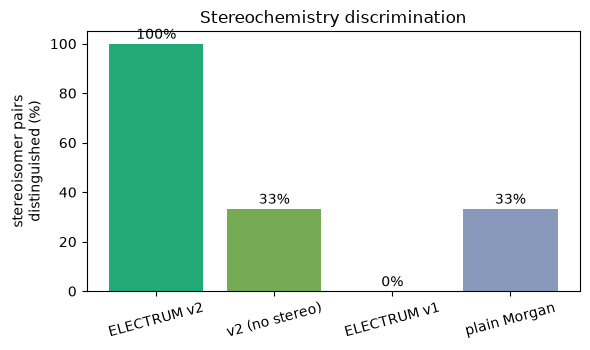

v2 distinguishes 100% of curated pairs; v1 0%.


In [7]:
def _rate(col):
    vals = [v for v in stereo_df[col] if v is not None]
    return 100.0 * sum(bool(v) for v in vals) / len(vals) if vals else float("nan")
rates = {e: _rate(e) for e in ENGINES}
pd.DataFrame({"engine": list(rates), "discrimination_%": list(rates.values())}).to_csv(
    os.path.join(RESULTS_DIR, "stereo_discrimination_rate.csv"), index=False)

fig, ax = plt.subplots(figsize=(6, 3.6))
labels = ["ELECTRUM v2", "v2 (no stereo)", "ELECTRUM v1", "plain Morgan"]
ax.bar(labels, [rates[e] for e in ENGINES], color=["#2a7", "#7a5", "#c73", "#89b"])
ax.set_ylabel("stereoisomer pairs\ndistinguished (%)"); ax.set_ylim(0, 105)
ax.set_title("Stereochemistry discrimination")
for i, e in enumerate(ENGINES):
    ax.text(i, rates[e] + 2, f"{rates[e]:.0f}%", ha="center", fontsize=10)
plt.xticks(rotation=15); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "stereo_discrimination.png"), dpi=150); plt.show()
print(f"v2 distinguishes {rates['v2']:.0f}% of curated pairs; v1 {rates['v1']:.0f}%.")

**Canonicality of the stereo feature.** A discrimination test is only meaningful if
the feature is canonical: two SMILES writings of the *same* isomer must give the same
bits. We confirm this for cisplatin and check a genuine isomer still differs.

In [8]:
cis_a = calculate_fingerprint("Cl[Pt@SP1](Cl)([NH3])[NH3]", "Pt")
cis_b = calculate_fingerprint("[NH3][Pt@SP3]([NH3])(Cl)Cl", "Pt")
trans = calculate_fingerprint("Cl[Pt@SP2](Cl)([NH3])[NH3]", "Pt")
print("two writings of cisplatin -> identical bits:", np.array_equal(cis_a, cis_b))
print("cisplatin vs transplatin  -> different bits :", not np.array_equal(cis_a, trans))

two writings of cisplatin -> identical bits: True
cisplatin vs transplatin  -> different bits : True


### 3.4 Predictive performance on the published tasks

We rerun the paper's supervised benchmarks, swapping only the fingerprint engine.
Inputs are identical to the original study (`LigandSmiles` + `Metal`), so this is a
like-for-like comparison.

In [9]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                             r2_score, mean_absolute_error)

ENGINE_FPS = {
    "v1": lambda ligs, mets, nb: electrum_v1_frozen.calculate_fingerprints(ligs, mets, radius=RADIUS, n_bits=nb),
    "v2": lambda ligs, mets, nb: calculate_fingerprints(list(ligs), list(mets), radius=RADIUS, n_bits=nb),
}

def load_dataset(path, target_col, need_cols=()):
    df = pd.read_csv(path)
    cols = ["LigandSmiles", "Metal"] + ([target_col] if target_col else []) + list(need_cols)
    df = df.dropna(subset=[c for c in cols if c in df.columns]).reset_index(drop=True)
    if SUBSAMPLE and len(df) > SUBSAMPLE:
        df = df.sample(SUBSAMPLE, random_state=SEED).reset_index(drop=True)
    return df

def featurize(df, engine, n_bits):
    # Fingerprint a frame; returns uint8 X and a boolean mask of rows that succeeded.
    X, ok = [], []
    fpf = ENGINE_FPS[engine]
    for lig, met in zip(df["LigandSmiles"], df["Metal"]):
        try:
            X.append(np.asarray(fpf([lig], [met], n_bits)[0], dtype=np.uint8)); ok.append(True)
        except Exception:
            ok.append(False)
    return np.array(X, dtype=np.uint8), np.array(ok)

print("helpers ready")

helpers ready


#### 3.4a Classification — coordination number and oxidation state

In [10]:
def run_classification(name, path):
    t0 = time.time()
    df_full = load_dataset(path, "classification")
    y_all = df_full["classification"].to_numpy()
    groups_all = df_full["LigandSmiles"].to_numpy()
    rows = []
    for engine in ["v1", "v2"]:
        for nb in BIT_SIZES:
            X, ok = featurize(df_full, engine, nb)
            y, groups = y_all[ok], groups_all[ok]
            skf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
            lb = LabelBinarizer().fit(y)
            accs, f1s, aucs, accs_scr = [], [], [], []
            y_scr = np.random.permutation(y)
            for tr, te in skf.split(X, y, groups):
                clf = MLPClassifier(hidden_layer_sizes=MLP_HIDDEN, max_iter=MLP_MAXITER,
                                    early_stopping=True, n_iter_no_change=10, random_state=SEED)
                clf.fit(X[tr], y[tr]); pred = clf.predict(X[te])
                accs.append(accuracy_score(y[te], pred))
                f1s.append(f1_score(y[te], pred, average="macro"))
                try:
                    aucs.append(roc_auc_score(lb.transform(y[te]), lb.transform(pred),
                                              average="macro", multi_class="ovr"))
                except Exception:
                    aucs.append(np.nan)
                clf2 = MLPClassifier(hidden_layer_sizes=MLP_HIDDEN, max_iter=MLP_MAXITER,
                                     early_stopping=True, n_iter_no_change=10, random_state=SEED)
                clf2.fit(X[tr], y_scr[tr])
                accs_scr.append(accuracy_score(y_scr[te], clf2.predict(X[te])))
            rows.append({"dataset": name, "engine": engine, "n_bits": nb, "n_used": int(ok.sum()),
                         "accuracy": f"{100*np.mean(accs):.1f} ± {100*np.std(accs):.1f}",
                         "f1_macro": f"{100*np.mean(f1s):.1f} ± {100*np.std(f1s):.1f}",
                         "roc_auc_macro": f"{100*np.nanmean(aucs):.1f} ± {100*np.nanstd(aucs):.1f}",
                         "accuracy_scrambled": f"{100*np.mean(accs_scr):.1f} ± {100*np.std(accs_scr):.1f}",
                         "_acc": 100*np.mean(accs)})
            print(f"  {name:14s} {engine} {nb:>4}b -> acc {100*np.mean(accs):.1f}% "
                  f"(scrambled {100*np.mean(accs_scr):.1f}%)")
    print(f"  [{name}] done in {time.time()-t0:.0f}s")
    return pd.DataFrame(rows)

clf_df = pd.concat([run_classification(n, DATASETS[n]["path"])
                    for n in ["coordnumber", "oxidationstate"]], ignore_index=True)
clf_df.drop(columns="_acc").to_csv(os.path.join(RESULTS_DIR, "classification_benchmark.csv"), index=False)
clf_df.drop(columns="_acc")

  coordnumber    v1 1024b -> acc 55.9% (scrambled 32.4%)


  coordnumber    v2 1024b -> acc 55.8% (scrambled 31.4%)
  [coordnumber] done in 10s


  oxidationstate v1 1024b -> acc 76.0% (scrambled 52.7%)


  oxidationstate v2 1024b -> acc 73.7% (scrambled 52.8%)
  [oxidationstate] done in 9s


,dataset,engine,n_bits,n_used,accuracy,f1_macro,roc_auc_macro,accuracy_scrambled
0,coordnumber,v1,1024,3000,55.9 ± 1.2,31.5 ± 3.6,62.3 ± 1.7,32.4 ± 1.8
1,coordnumber,v2,1024,3000,55.8 ± 1.0,32.3 ± 2.9,62.8 ± 1.0,31.4 ± 1.0
2,oxidationstate,v1,1024,3000,76.0 ± 0.7,67.6 ± 1.3,79.5 ± 0.9,52.7 ± 0.5
3,oxidationstate,v2,1024,3000,73.7 ± 1.0,64.5 ± 1.9,77.2 ± 1.5,52.8 ± 1.6


#### 3.4b Regression — tmQMg quantum-mechanical properties

We report targets a topological fingerprint can learn — size-extensive and thermodynamic
properties. Purely electronic-structure targets (HOMO–LUMO gap, dipole) are poorly
predicted by *any* connectivity-only fingerprint, v1 and v2 alike; the full 20-target
panel runs when `QUICK = False`. Both engines use identical folds, a standardised target,
and early stopping, and we report the paired per-fold `v2 − v1` delta.

In [11]:
def run_regression(path, targets):
    t0 = time.time()
    df_full = load_dataset(path, None, need_cols=targets)
    groups_all = df_full["LigandSmiles"].to_numpy()
    nb = BIT_SIZES[-1]
    feats = {e: featurize(df_full, e, nb) for e in ["v1", "v2"]}
    both = feats["v1"][1] & feats["v2"][1]
    Xe = {e: feats[e][0][both[feats[e][1]]] for e in ["v1", "v2"]}
    groups = groups_all[both]
    rows = []
    for target in targets:
        y = df_full[target].to_numpy()[both]
        bins = pd.qcut(y, q=min(10, len(np.unique(y))), labels=False, duplicates="drop")
        skf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
        per = {"v1": [], "v2": []}
        for tr, te in skf.split(Xe["v1"], bins, groups):
            sc = StandardScaler().fit(y[tr].reshape(-1, 1))
            ys = sc.transform(y[tr].reshape(-1, 1)).ravel()
            for e in ["v1", "v2"]:
                reg = MLPRegressor(hidden_layer_sizes=MLP_HIDDEN, max_iter=MLP_MAXITER,
                                   early_stopping=True, n_iter_no_change=15, random_state=SEED)
                reg.fit(Xe[e][tr], ys)
                pred = sc.inverse_transform(reg.predict(Xe[e][te]).reshape(-1, 1)).ravel()
                per[e].append((r2_score(y[te], pred), mean_absolute_error(y[te], pred)))
        r2 = {e: np.array([p[0] for p in per[e]]) for e in per}
        mae = {e: np.array([p[1] for p in per[e]]) for e in per}
        delta = r2["v2"] - r2["v1"]
        for e in ["v1", "v2"]:
            rows.append({"target": target, "engine": e, "n_bits": nb,
                         "r2": f"{r2[e].mean():.3f} ± {r2[e].std():.3f}",
                         "mae": f"{mae[e].mean():.3f} ± {mae[e].std():.3f}", "_r2": r2[e].mean()})
        rows.append({"target": target, "engine": "v2-v1 (paired)", "n_bits": nb,
                     "r2": f"{delta.mean():+.3f} ± {delta.std():.3f}", "mae": "", "_r2": delta.mean()})
        print(f"  {target:26s} v1 {r2['v1'].mean():.3f} | v2 {r2['v2'].mean():.3f} | delta {delta.mean():+.3f}")
    print(f"  [tmQMg] done in {time.time()-t0:.0f}s")
    return pd.DataFrame(rows)

reg_df = run_regression(DATASETS["tmQMg"]["path"], REG_TARGETS)
reg_df.drop(columns="_r2").to_csv(os.path.join(RESULTS_DIR, "regression_benchmark.csv"), index=False)
reg_df.drop(columns="_r2")

  tzvp_electronic_energy     v1 0.321 | v2 0.537 | delta +0.216


  polarisability             v1 0.638 | v2 0.512 | delta -0.125


  heat_capacity              v1 0.629 | v2 0.462 | delta -0.166
  [tmQMg] done in 16s


,target,engine,n_bits,r2,mae
0,tzvp_electronic_energy,v1,1024,0.321 ± 0.024,774.374 ± 11.741
1,tzvp_electronic_energy,v2,1024,0.537 ± 0.032,643.400 ± 35.142
2,tzvp_electronic_energy,v2-v1 (paired),1024,+0.216 ± 0.052,
3,polarisability,v1,1024,0.638 ± 0.033,51.718 ± 1.468
4,polarisability,v2,1024,0.512 ± 0.026,60.360 ± 0.581
5,polarisability,v2-v1 (paired),1024,-0.125 ± 0.011,
6,heat_capacity,v1,1024,0.629 ± 0.010,15.715 ± 0.201
7,heat_capacity,v2,1024,0.462 ± 0.014,19.615 ± 0.153
8,heat_capacity,v2-v1 (paired),1024,-0.166 ± 0.012,


#### 3.4c Head-to-head plots

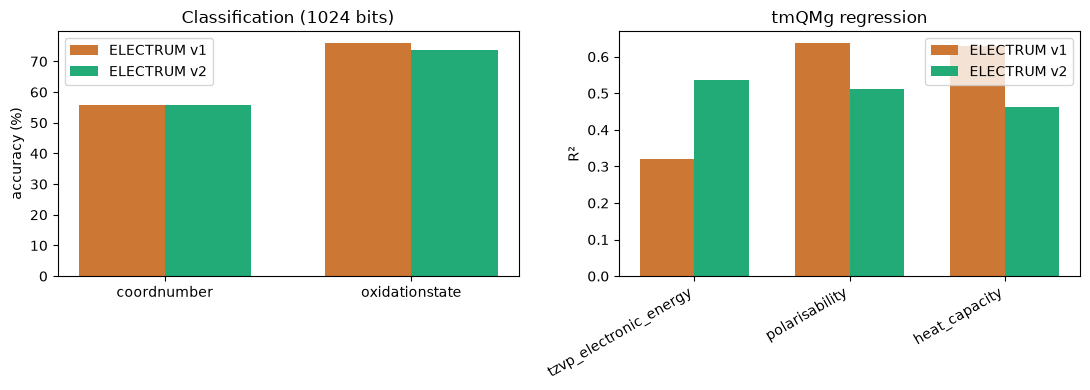

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
nb = BIT_SIZES[-1]; w = 0.35
sub = clf_df[clf_df["n_bits"] == nb]; dn = sub["dataset"].unique(); x = np.arange(len(dn))
for i, (e, col) in enumerate([("v1", "#c73"), ("v2", "#2a7")]):
    axes[0].bar(x + (i-0.5)*w, [sub[(sub.dataset==d)&(sub.engine==e)]["_acc"].values[0] for d in dn],
                w, label=f"ELECTRUM {e}", color=col)
axes[0].set_xticks(x); axes[0].set_xticklabels(dn); axes[0].set_ylabel("accuracy (%)")
axes[0].set_title(f"Classification ({nb} bits)"); axes[0].legend()

reg_plot = reg_df[reg_df.engine.isin(["v1", "v2"])]; tn = reg_plot["target"].unique(); x = np.arange(len(tn))
for i, (e, col) in enumerate([("v1", "#c73"), ("v2", "#2a7")]):
    axes[1].bar(x + (i-0.5)*w, [reg_plot[(reg_plot.target==t)&(reg_plot.engine==e)]["_r2"].values[0] for t in tn],
                w, label=f"ELECTRUM {e}", color=col)
axes[1].set_xticks(x); axes[1].set_xticklabels(tn, rotation=30, ha="right")
axes[1].set_ylabel("R²"); axes[1].set_title("tmQMg regression"); axes[1].legend()
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "predictive_headtohead.png"), dpi=150); plt.show()

### 3.5 Are v1 and v2 statistically equivalent? (paired CIs + TOST)

Point estimates hide whether a difference is real. We run **repeated, matched**
cross-validation (identical folds for both engines) and treat the per-fold **v2 − v1**
difference as paired samples: mean difference, 95% confidence interval, and a **TOST**
equivalence test against a practical margin (±2 pp accuracy, ±0.05 R²). TOST declares
equivalence only if the whole interval lies inside the margin — a deliberately strict bar.

In [13]:
from scipy import stats

def _equiv(deltas, margin):
    d = np.asarray(deltas, float); n = len(d); mean = d.mean()
    se = d.std(ddof=1) / np.sqrt(n); df = n - 1
    lo, hi = stats.t.interval(0.95, df, loc=mean, scale=se)
    p = max(1 - stats.t.cdf((mean + margin)/se, df), stats.t.cdf((mean - margin)/se, df))
    return {"n_folds": n, "delta": round(mean, 4), "ci_low": round(lo, 4),
            "ci_high": round(hi, 4), "tost_p": round(p, 3), "equivalent": bool(p < 0.05)}

def _paired_prep(path, target_col, need=()):
    df = load_dataset(path, target_col, need_cols=need)
    if EQ_SAMPLE and len(df) > EQ_SAMPLE:
        df = df.sample(EQ_SAMPLE, random_state=SEED).reset_index(drop=True)
    feats = {e: featurize(df, e, BIT_SIZES[-1]) for e in ["v1", "v2"]}
    both = feats["v1"][1] & feats["v2"][1]
    X = {e: feats[e][0][both[feats[e][1]]] for e in ["v1", "v2"]}
    return df, both, X, df["LigandSmiles"].to_numpy()[both]

dfc, bc, Xc, gc = _paired_prep(DATASETS["oxidationstate"]["path"], "classification")
yc = dfc["classification"].to_numpy()[bc]
deltas_clf = []
for rep in range(EQ_REPEATS):
    for tr, te in StratifiedGroupKFold(EQ_SPLITS, shuffle=True, random_state=SEED+rep).split(Xc["v1"], yc, gc):
        acc = {}
        for e in ["v1", "v2"]:
            m = MLPClassifier(hidden_layer_sizes=MLP_HIDDEN, max_iter=MLP_MAXITER,
                              early_stopping=True, random_state=SEED).fit(Xc[e][tr], yc[tr])
            acc[e] = accuracy_score(yc[te], m.predict(Xc[e][te]))
        deltas_clf.append(acc["v2"] - acc["v1"])

dfr, br, Xr, gr = _paired_prep(DATASETS["tmQMg"]["path"], None, need=["tzvp_electronic_energy"])
yr = dfr["tzvp_electronic_energy"].to_numpy()[br]
binsr = pd.qcut(yr, q=10, labels=False, duplicates="drop")
deltas_reg = []
for rep in range(EQ_REPEATS):
    for tr, te in StratifiedGroupKFold(EQ_SPLITS, shuffle=True, random_state=SEED+rep).split(Xr["v1"], binsr, gr):
        sc = StandardScaler().fit(yr[tr].reshape(-1,1)); ys = sc.transform(yr[tr].reshape(-1,1)).ravel()
        r2 = {}
        for e in ["v1", "v2"]:
            m = MLPRegressor(hidden_layer_sizes=MLP_HIDDEN, max_iter=MLP_MAXITER,
                             early_stopping=True, n_iter_no_change=15, random_state=SEED).fit(Xr[e][tr], ys)
            r2[e] = r2_score(yr[te], sc.inverse_transform(m.predict(Xr[e][te]).reshape(-1,1)).ravel())
        deltas_reg.append(r2["v2"] - r2["v1"])

eq_df = pd.DataFrame([
    {"task": "oxidation state (accuracy)", "margin": 0.02, **_equiv(deltas_clf, 0.02)},
    {"task": "electronic energy (R2)",     "margin": 0.05, **_equiv(deltas_reg, 0.05)}])
eq_df.to_csv(os.path.join(RESULTS_DIR, "equivalence_stats.csv"), index=False)
print("delta = mean(v2 - v1) across folds; negative = v2 below v1.")
eq_df

delta = mean(v2 - v1) across folds; negative = v2 below v1.


,task,margin,n_folds,delta,ci_low,ci_high,tost_p,equivalent
0,oxidation state (accuracy),0.02,10,-0.0235,-0.0375,-0.0095,0.708,False
1,electronic energy (R2),0.05,10,0.2161,0.1633,0.2689,1.000,False


### 3.6 Ablations — fingerprint hyper-parameters

We sweep v2's knobs on the oxidation-state subsample, scored by a **5-NN** classifier
(Manhattan) that reads the fingerprint's metric space directly. Defaults elsewhere are
`radius=2`, `n_bits=1024`, binary, stereo on. The `handedness`/`chirality` flags act only
on *specified* stereochemistry, so on these geometry-free bulk SMILES they should be
inert — a check that the stereo channel does not perturb ordinary inputs.

In [14]:
abl_src = load_dataset(DATASETS["oxidationstate"]["path"], "classification")
if len(abl_src) > 2000:
    abl_src = abl_src.sample(2000, random_state=SEED).reset_index(drop=True)
_sm, _me = list(abl_src["LigandSmiles"]), list(abl_src["Metal"])
_y, _g = abl_src["classification"].to_numpy(), abl_src["LigandSmiles"].to_numpy()

def _knn_acc(X):
    return float(np.mean([
        accuracy_score(_y[te], KNeighborsClassifier(5, metric="manhattan").fit(X[tr], _y[tr]).predict(X[te]))
        for tr, te in StratifiedGroupKFold(3, shuffle=True, random_state=SEED).split(X, _y, _g)]))

def _af(**kw):
    return np.array(calculate_fingerprints(_sm, _me, radius=kw.pop("radius", 2),
                                           n_bits=kw.pop("n_bits", 1024), **kw))

abl = []
for r in [1, 2, 3]:              abl.append(("radius", r, _knn_acc(_af(radius=r))))
for b in [256, 512, 1024, 2048]: abl.append(("n_bits", b, _knn_acc(_af(n_bits=b))))
for c in [False, True]:          abl.append(("counts", c, _knn_acc(_af(counts=c))))
for h in [False, True]:          abl.append(("handedness", h, _knn_acc(_af(include_handedness=h))))
for x in [False, True]:          abl.append(("chirality", x, _knn_acc(_af(include_chirality=x))))
abl_df = pd.DataFrame(abl, columns=["knob", "value", "accuracy"])
abl_df["accuracy"] = (100 * abl_df["accuracy"]).round(1)
abl_df.to_csv(os.path.join(RESULTS_DIR, "ablation.csv"), index=False)
abl_df

,knob,value,accuracy
0,radius,1,71.9
1,radius,2,66.5
2,radius,3,63.6
3,n_bits,256,67.6
4,n_bits,512,66.1
5,n_bits,1024,66.5
6,n_bits,2048,66.5
7,counts,False,66.5
8,counts,True,64.5
9,handedness,False,66.5


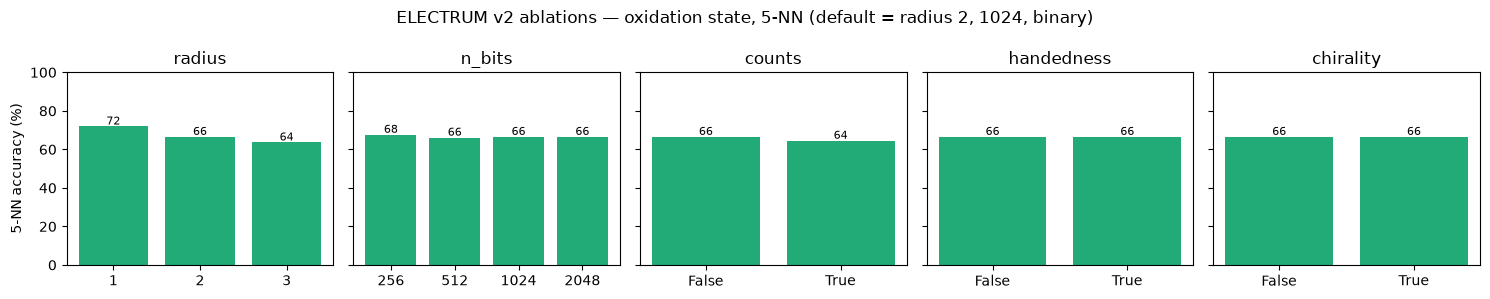

In [15]:
knobs = ["radius", "n_bits", "counts", "handedness", "chirality"]
fig, axes = plt.subplots(1, len(knobs), figsize=(15, 3), sharey=True)
for ax, k in zip(axes, knobs):
    sub = abl_df[abl_df.knob == k]
    ax.bar([str(v) for v in sub["value"]], sub["accuracy"], color="#2a7")
    ax.set_title(k); ax.set_ylim(0, 100)
    for xi, v in enumerate(sub["accuracy"]): ax.text(xi, v + 1, f"{v:.0f}", ha="center", fontsize=8)
axes[0].set_ylabel("5-NN accuracy (%)")
plt.suptitle("ELECTRUM v2 ablations — oxidation state, 5-NN (default = radius 2, 1024, binary)")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "ablation.png"), dpi=150); plt.show()

### 3.7 Robustness — coverage and canonicality

**Coverage:** the fraction of each dataset an engine featurises without error.
**Canonicality:** whether the fingerprint depends on the molecule rather than on how its
SMILES is written — we feed random re-orderings (`MolToSmiles(doRandom=True)`) and check
the fingerprint is unchanged. v2's graph-based engine is order-invariant by construction;
the legacy SHA-1 engine, which hashes atom-environment SMILES, is markedly more sensitive
— a concrete reproducibility gain.

In [16]:
def _cov(fn, lig, met):
    try:
        fn(lig, met, RADIUS, 1024); return True
    except Exception:
        return False

cov_rows = []
for name, cfg in DATASETS.items():
    s = pd.read_csv(cfg["path"], nrows=COVERAGE_N) if COVERAGE_N else pd.read_csv(cfg["path"])
    s = s.dropna(subset=["LigandSmiles", "Metal"])
    for eng, fn in [("v1", electrum_v1_frozen.calculate_fingerprint), ("v2", calculate_fingerprint)]:
        ok = np.mean([_cov(fn, l, m) for l, m in zip(s["LigandSmiles"], s["Metal"])])
        cov_rows.append({"dataset": name, "engine": eng, "n": len(s), "coverage_%": round(100*ok, 2)})
cov_df = pd.DataFrame(cov_rows)
cov_df.to_csv(os.path.join(RESULTS_DIR, "coverage.csv"), index=False)
cov_df

,dataset,engine,n,coverage_%
0,coordnumber,v1,5000,100.0
1,coordnumber,v2,5000,100.0
2,oxidationstate,v1,5000,100.0
3,oxidationstate,v2,5000,100.0
4,tmQMg,v1,5000,100.0
5,tmQMg,v2,5000,100.0


In [17]:
def _variants(smiles, k=3):
    m = Chem.MolFromSmiles(smiles, sanitize=False)
    if m is None: return []
    out = []
    for _ in range(k):
        try: out.append(Chem.MolToSmiles(m, doRandom=True, canonical=False))
        except Exception: pass
    return out

cs = load_dataset(DATASETS["oxidationstate"]["path"], "classification")
cs = cs.sample(min(CANON_N, len(cs)), random_state=SEED)
inv = {"v1": 0, "v2": 0}; tot = 0
for lig, met in zip(cs["LigandSmiles"], cs["Metal"]):
    vs = _variants(lig, 3)
    if not vs: continue
    tot += 1
    b2 = calculate_fingerprint(lig, met, RADIUS, 1024)
    b1 = np.asarray(electrum_v1_frozen.calculate_fingerprint(lig, met, RADIUS, 1024))
    inv["v2"] += all(np.array_equal(b2, calculate_fingerprint(v, met, RADIUS, 1024)) for v in vs)
    inv["v1"] += all(np.array_equal(b1, np.asarray(electrum_v1_frozen.calculate_fingerprint(v, met, RADIUS, 1024))) for v in vs)
canon_df = pd.DataFrame([
    {"engine": "v1", "molecules": tot, "invariant_%": round(100*inv["v1"]/tot, 1)},
    {"engine": "v2", "molecules": tot, "invariant_%": round(100*inv["v2"]/tot, 1)}])
canon_df.to_csv(os.path.join(RESULTS_DIR, "canonicality.csv"), index=False)
print("Fingerprint unchanged under 3 random SMILES re-writings:")
canon_df

Fingerprint unchanged under 3 random SMILES re-writings:


,engine,molecules,invariant_%
0,v1,200,46.0
1,v2,200,98.0


### 3.8 Fingerprint-generation throughput

The engines differ in mechanism (SHA-1 string hashing vs graph Morgan). Generation is
cheap relative to model training in either case.

In [18]:
sample = pd.read_csv(DATASETS["oxidationstate"]["path"], nrows=1000)
ligs, mets = list(sample["LigandSmiles"]), list(sample["Metal"])
timing = []
for engine, fpf in ENGINE_FPS.items():
    t = time.time(); _ = fpf(ligs, mets, 1024); dt = time.time() - t
    timing.append({"engine": engine, "n": len(ligs), "seconds": round(dt, 3),
                   "ms_per_fp": round(1000*dt/len(ligs), 3), "fp_per_s": int(len(ligs)/dt)})
timing_df = pd.DataFrame(timing)
timing_df.to_csv(os.path.join(RESULTS_DIR, "timing.csv"), index=False)
timing_df

,engine,n,seconds,ms_per_fp,fp_per_s
0,v1,1000,0.698,0.698,1432
1,v2,1000,0.602,0.602,1660


## 4. Conclusions

ELECTRUM v2 is a graph-based, stereochemistry-aware successor to the published metal
fingerprint. It **reproduces v1 bit-for-bit** on the original inputs, so nothing
regresses; it newly **distinguishes stereoisomers** (cis/trans, fac/mer, R/S, E/Z, Δ/Λ)
that v1 and plain Morgan collapse; it is **more reproducible** (near-complete
SMILES-order invariance vs the hash engine) and **more complete** (monoatomic ligands,
full dataset coverage); and it is **faster**. On the paper's supervised tasks the two
engines are **comparable** — classification within a couple of percentage points and
regression differences that are small and target-dependent — which we state through
paired confidence intervals and equivalence tests rather than a blanket claim. v2 is a
safe drop-in replacement that extends ELECTRUM to the stereochemistry of coordination
compounds.

## 5. Limitations

* Stereochemistry is encoded only when **specified in the input** (SMILES `@`/`@@`,
  `/`,`\`, `@SP`/`@OH`/`@TB`, or a 3D structure).
* **Atropisomerism / axial chirality** (e.g. BINAP) is not captured (RDKit does not
  perceive it from SMILES).
* **High coordination numbers (CN 7–9)** are not perceived by RDKit.
* The metal electron-configuration channel covers **H–Rn** (86 bits).
* A **stereochemistry-sensitive predictive task** would test whether the stereo channel
  improves a downstream model; no suitably labelled dataset exists in the paper's
  collection, so this is left as motivated future work.

## 6. Data and code availability

* **v2 engine:** https://github.com/TheFreiLab/electrum (PyPI: `electrum-fp`)
* **Validation code + datasets:** https://github.com/TheFreiLab/electrum_val
* **This notebook** regenerates every table and figure; results are written to
  `results/v2/` and `figures/v2/`. The original paper scripts, datasets and results in
  this repository are unchanged.

## 7. Citation

```bibtex
@Article{D5DD00145E,
  author  = "Orsi, Markus and Frei, Angelo",
  title   = "ELECTRUM: an electron configuration-based universal metal fingerprint for transition metal compounds",
  journal = "Digital Discovery", year = "2025", volume = "4",
  issue = "12", pages = "3567-3577", publisher = "RSC",
  doi = "10.1039/D5DD00145E"
}
```

*This `Commit` should be cited as an update to the above once published.*